# Uniform Train/Val/Test split for all models
- Global distribution of profiles is unbalanced
- distribution of profiles to clusters (target-variable) is also unbalanced and train/test sets should have equal representations of each cluster

**Aim**:
- Training and test data should both have Profiles from equal geographical distributions (Laitude, Longitude, MarineRegion) and environmental clusters
- Validation data: use of cross-validation, assign validation-block ids to Profiles

**Output of this notebook:**
- table with Profile_id -> data_type matching (data_type is either train or test, training data has additional value in column CV_fold, specifying the CV block)


In [1]:
import pandas as pd
data = pd.read_pickle('../Data/Environmental_data_depth_resolved_subset.pkl')
data['Profile_id'] = data['Profile_id'].astype(str)
data['datetime'] = pd.to_datetime(data['datetime'])

# merge clusters with mapping to see which profiles are in which cluster and data_type
clusters = pd.read_pickle('../Data/Profile_id_to_clusters.pkl')
data = clusters.merge(data, on="Profile_id", how='left')
#data.info()

# only keep columns "Profile_id, Latitude, Longitude, datetime, Cruise" and drop duplicates
data = data[["Profile_id", "Latitude", "Longitude", "datetime", "Cruise", "MarineRegion","cluster"]].drop_duplicates()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5613 entries, 0 to 224480
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Profile_id    5613 non-null   object        
 1   Latitude      5613 non-null   float64       
 2   Longitude     5613 non-null   float64       
 3   datetime      5613 non-null   datetime64[ns]
 4   Cruise        5613 non-null   object        
 5   MarineRegion  5613 non-null   object        
 6   cluster       5613 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(1), object(3)
memory usage: 328.9+ KB


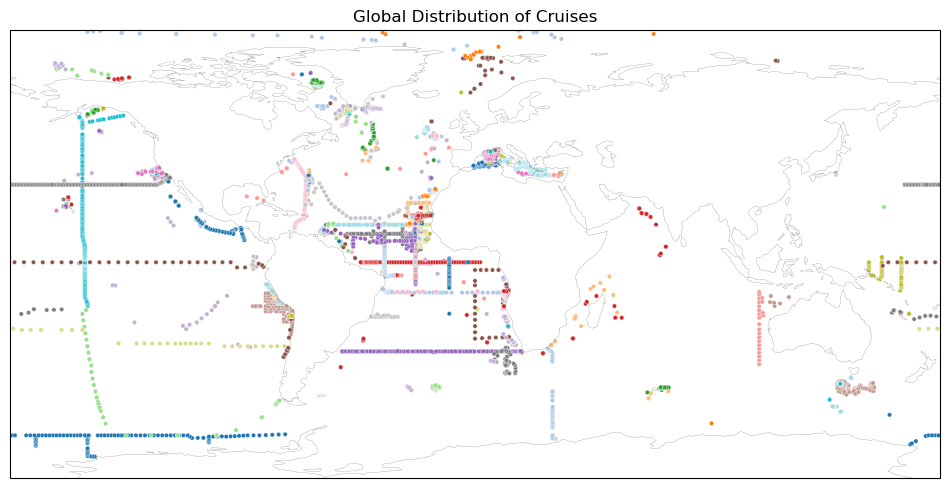

C:\Users\bthobor\AppData\Local\Temp\ipykernel_1272\913431845.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


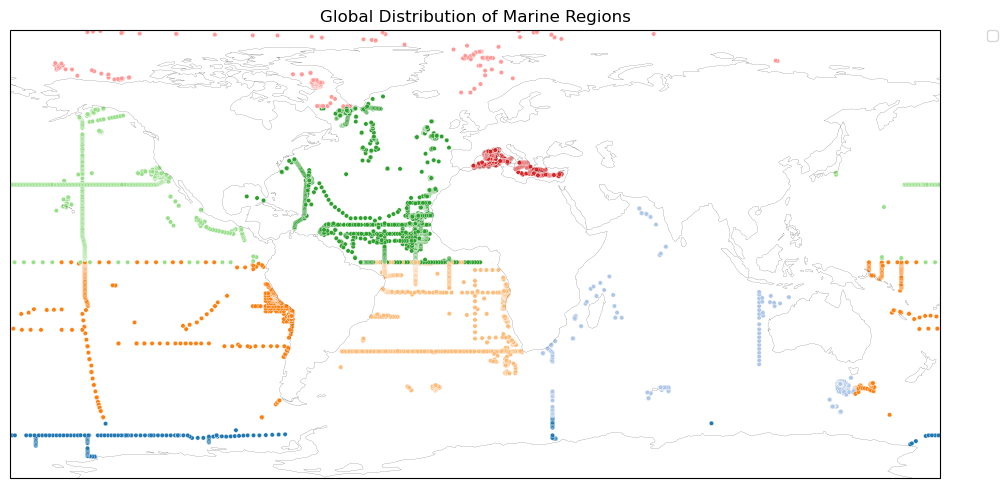

C:\Users\bthobor\AppData\Local\Temp\ipykernel_1272\913431845.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, y='MarineRegion', order=data['MarineRegion'].value_counts().index, palette=marine_region_colors)


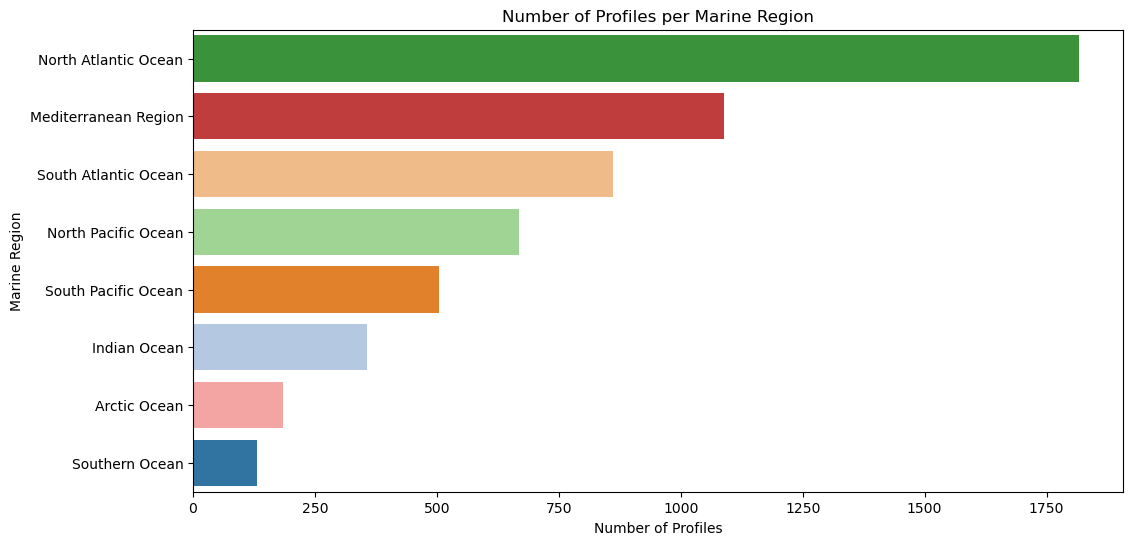

In [8]:
# plot global distribution of Cruises
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))

# plot world map as background from cartopy
import cartopy.crs as ccrs
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(color='black', linewidth=0.1)
sns.scatterplot(data=data, x='Longitude', y='Latitude', hue='Cruise', palette='tab20', legend=None, s = 10)
plt.title('Global Distribution of Cruises')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# create a color map for MarineRegion (matching colors to MarineRegion names)
marine_region_colors = dict(zip(data['MarineRegion'].unique(), sns.color_palette('tab20', n_colors=data['MarineRegion'].nunique())))

plt.figure(figsize=(12,6))
# plot world map as background from cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(color='black', linewidth=0.1)
sns.scatterplot(data=data, x='Longitude', y='Latitude', hue='MarineRegion', palette=marine_region_colors, legend=None, s = 10)
plt.title('Global Distribution of Marine Regions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
# legend showing MarineRegion names and colors outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

# bar chart of number of profiles per marine region
plt.figure(figsize=(12,6))
sns.countplot(data=data, y='MarineRegion', order=data['MarineRegion'].value_counts().index, palette=marine_region_colors)
plt.title('Number of Profiles per Marine Region')
plt.xlabel('Number of Profiles')
plt.ylabel('Marine Region')
plt.show()

## Train-test split

Total profiles:  5613; target TEST profiles ≈ 1403
Starting greedy selection...
Target cluster distribution: {1: 268, 8: 221, 9: 163, 6: 151, 3: 147, 2: 113, 5: 103, 0: 92, 4: 80, 7: 65}
Progress: 10% (140/1403 profiles selected)
Progress: 20% (280/1403 profiles selected)
Progress: 30% (420/1403 profiles selected)
Progress: 40% (561/1403 profiles selected)
Progress: 50% (701/1403 profiles selected)
Progress: 60% (841/1403 profiles selected)
Progress: 70% (982/1403 profiles selected)
Progress: 80% (1122/1403 profiles selected)
Progress: 90% (1262/1403 profiles selected)
Progress: 100% (1403/1403 profiles selected)
Selection completed:  1403 profiles selected
Final cluster counts: {np.int32(5): 103, np.int32(4): 80, np.int32(9): 163, np.int32(3): 147, np.int32(2): 113, np.int32(8): 221, np.int32(6): 151, np.int32(1): 268, np.int32(7): 65, np.int32(0): 92}
Greedy selection info: {'combined_score': 13893.0, 'geo_score': 13893.0, 'cluster_score': 0, 'n_test': 1403, 'n_profiles_test': 1403}


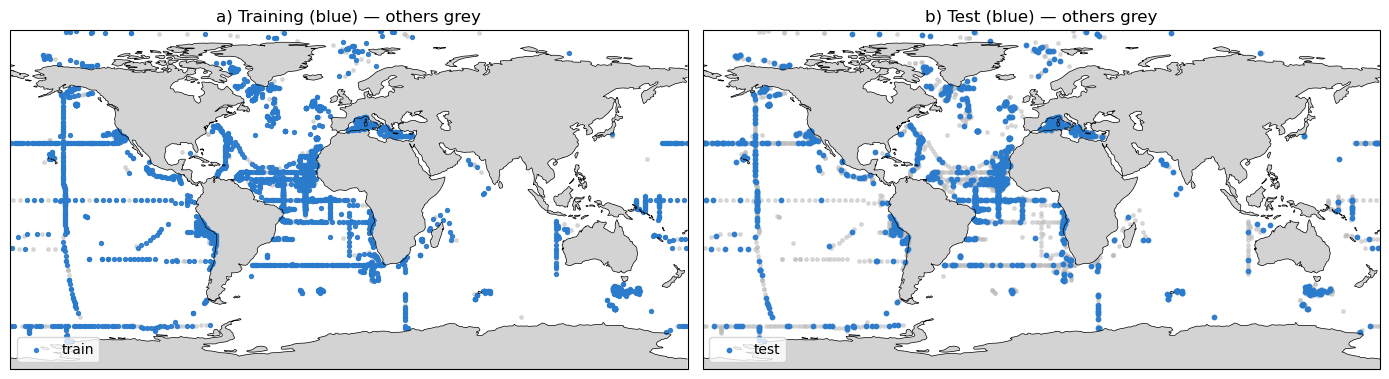


Full cluster counts:
cluster
0     367
1    1072
2     452
3     590
4     319
5     411
6     606
7     259
8     883
9     654
Name: count, dtype: int64

Test cluster counts:
cluster
0     92
1    268
2    113
3    147
4     80
5    103
6    151
7     65
8    221
9    163
Name: count, dtype: int64

Test cluster proportions vs full proportions:
  Cluster 0: Full 6.5%, Test 6.6% (diff: 0.0%)
  Cluster 1: Full 19.1%, Test 19.1% (diff: 0.0%)
  Cluster 2: Full 8.1%, Test 8.1% (diff: 0.0%)
  Cluster 3: Full 10.5%, Test 10.5% (diff: -0.0%)
  Cluster 4: Full 5.7%, Test 5.7% (diff: 0.0%)
  Cluster 5: Full 7.3%, Test 7.3% (diff: 0.0%)
  Cluster 6: Full 10.8%, Test 10.8% (diff: -0.0%)
  Cluster 7: Full 4.6%, Test 4.6% (diff: 0.0%)
  Cluster 8: Full 15.7%, Test 15.8% (diff: 0.0%)
  Cluster 9: Full 11.7%, Test 11.6% (diff: -0.0%)


In [12]:
"""
Notebook-friendly:  select TEST profiles by sampling Profile_ids,
balancing geographic coverage (absolute-lat bins + lon bins / spatial grid) AND cluster
distribution (target variable). Saves mapping pickle and shows a 2-panel map. 

Behavior:
- Uses `data` DataFrame already loaded in the notebook (must contain columns: 
  Profile_id, Latitude, Longitude, datetime, cluster).
- Builds absolute-latitude bins on |Latitude| using LAT_BIN_EDGES. 
- Builds longitude bins (LON_BIN_WIDTH) and a combined spatial bin (lat_abs_bin | lon_bin).
- Greedy selection picks Profile_ids for TEST to: 
    * Match cluster frequency in TEST to the full-data cluster distribution (primary if CLUSTER_WEIGHT large),
    * Achieve geographic coverage (lat/lon/spatial) and ensure every absolute-lat bin has >=1 profile
- After greedy selection, ensures every absolute-lat bin has at least one profile in TEST
- Saves a single pickle:  ../Data/profile_test_mapping.pkl with columns:  Profile_id, data_type ('test' or 'train').
- Shows two-panel inline map: 
    a) training in blue, other profiles grey
    b) test in blue, other profiles grey
"""

import os
import random
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional Cartopy for nicer maps; fallback to plain lat/lon scatter if not installed
HAS_CARTOPY = False
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False

# ---------------- CONFIG ----------------
RANDOM_SEED = 1
TEST_FRACTION = 0.25                # desired fraction of profiles in TEST
LAT_BIN_EDGES = [10, 30, 50, 70, 90]  # absolute-latitude edges in degrees (0.. 90)
LON_BIN_WIDTH = 20.0                # degrees per longitude bin
CLUSTER_WEIGHT = 3.0                # weight for cluster-distribution mismatch in combined score
GEO_WEIGHT = 1.0                    # weight for geographic mismatch
COVERAGE_PENALTY = 60.0             # penalty for missing geographic bins in score
SAMPLE_SIZE = 1000                  # sample size for large remaining sets (for speed)
OUT_DIR = "../Data"
OUT_PKL = os.path.join(OUT_DIR, "profile_test_mapping.pkl")
os.makedirs(OUT_DIR, exist_ok=True)
# ----------------------------------------

# Column names in `data` (must exist)
COL_PROFILE = "Profile_id"
COL_LAT = "Latitude"
COL_LON = "Longitude"
COL_DT = "datetime"
COL_CLUSTER = "cluster"

# ------- helper functions --------

def set_seed(s):
    random.seed(s)
    np.random.seed(s)

def check_input_df():
    if 'data' not in globals():
        raise RuntimeError("Please provide your dataframe as the variable `data` in the notebook.")
    df = globals()['data']
    if not isinstance(df, pd.DataFrame):
        raise RuntimeError("`data` exists but is not a pandas DataFrame.")
    missing = [c for c in [COL_PROFILE, COL_LAT, COL_LON, COL_DT, COL_CLUSTER] if c not in df.columns]
    if missing: 
        raise RuntimeError(f"Input dataframe `data` is missing required columns: {missing}")
    return df.copy()

def make_abs_lat_bins(df, edges):
    lat_abs = df[COL_LAT].abs().astype(float)
    edges_sorted = sorted(edges)
    if edges_sorted[0] != 0.0:
        edges_sorted = [0.0] + edges_sorted
    if edges_sorted[-1] < 90.0:
        edges_sorted = edges_sorted + [90.0]
    labels = []
    for i in range(len(edges_sorted)-1):
        labels.append(f"{int(edges_sorted[i])}-{int(edges_sorted[i+1])}")
    bins = pd.cut(lat_abs, bins=edges_sorted, labels=labels, include_lowest=True, right=False)
    return bins.astype(str)

def make_lon_bins(df, width_deg):
    lon = (pd.to_numeric(df[COL_LON], errors='coerce') + 180.0) % 360.0 - 180.0
    edges = np.arange(-180.0, 180.0 + 1e-6, width_deg)
    bins = pd.cut(lon, bins=edges, include_lowest=True, right=False)
    return bins.astype(str)

def summarize_geo(rows):
    return {
        'lat': rows['lat_abs_bin'].value_counts().to_dict(),
        'lon': rows['lon_bin'].value_counts().to_dict(),
        'spatial': rows['spatial_bin'].value_counts().to_dict()
    }

def l1dist(a, b):
    keys = set(a.keys()) | set(b.keys())
    return sum(abs(a.get(k, 0) - b.get(k, 0)) for k in keys)

def coverage_misses(curr, target):
    keys = set(k for k, v in target.items() if v > 0)
    return sum(1 for k in keys if curr.get(k, 0) == 0)

def score_geo(current_counts, target_geo):
    d_lat = l1dist(current_counts['lat'], target_geo['lat'])
    d_lon = l1dist(current_counts['lon'], target_geo['lon'])
    d_sp = l1dist(current_counts['spatial'], target_geo['spatial'])
    c_lat = coverage_misses(current_counts['lat'], target_geo['lat'])
    c_lon = coverage_misses(current_counts['lon'], target_geo['lon'])
    c_sp = coverage_misses(current_counts['spatial'], target_geo['spatial'])
    return GEO_WEIGHT * (d_lat + 0.8 * d_lon + 1.5 * d_sp) + COVERAGE_PENALTY * (c_lat + c_lon + c_sp)

def score_cluster(current_cluster_counts, target_cluster_counts):
    return l1dist(current_cluster_counts, target_cluster_counts)

# ------- single greedy selection -------

def greedy_select_test_balanced(df, test_target_n):
    """
    Single greedy selection that combines cluster-distribution matching and geographic coverage.
    At each step, pick Profile_ID that minimizes combined_score = CLUSTER_WEIGHT * cluster_score + GEO_WEIGHT * geo_score
    """
    print("Starting greedy selection...")
    
    # Pre-compute target distributions
    target_geo = summarize_geo(df)
    full_cluster_counts = df[COL_CLUSTER].value_counts().to_dict()
    total_profiles = len(df)
    target_cluster = {k: int(round(v / total_profiles * test_target_n)) for k, v in full_cluster_counts.items()}
    # ensure at least 1 for clusters present overall
    for k, v in full_cluster_counts.items():
        if v > 0 and target_cluster.get(k, 0) == 0:
            target_cluster[k] = 1

    print(f"Target cluster distribution: {target_cluster}")

    # Get all profile IDs
    all_profiles = df[COL_PROFILE].tolist()
    
    # Initialize
    remaining_profiles = set(all_profiles)
    selected_profiles = set()
    current_geo = {'lat': defaultdict(int), 'lon': defaultdict(int), 'spatial': defaultdict(int)}
    current_cluster = defaultdict(int)
    current_n = 0

    # Progress tracking
    progress_intervals = [int(test_target_n * p) for p in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]]

    # Greedy loop:  select profile that gives best combined improvement
    while current_n < test_target_n and remaining_profiles:
        best_profile = None
        best_combined = float('inf')
        
        # To speed up, sample a subset of remaining profiles if too many
        if len(remaining_profiles) > SAMPLE_SIZE:
            sample_profiles = random.sample(list(remaining_profiles), SAMPLE_SIZE)
        else:
            sample_profiles = list(remaining_profiles)
        
        # Evaluate each remaining profile
        for profile_id in sample_profiles:
            # Get profile data
            profile_row = df[df[COL_PROFILE] == profile_id].iloc[0]
            
            # Trial geographic counts if we add this profile
            trial_geo = {
                'lat': dict(current_geo['lat']),
                'lon': dict(current_geo['lon']),
                'spatial': dict(current_geo['spatial'])
            }
            trial_geo['lat'][profile_row['lat_abs_bin']] = trial_geo['lat'].get(profile_row['lat_abs_bin'], 0) + 1
            trial_geo['lon'][profile_row['lon_bin']] = trial_geo['lon'].get(profile_row['lon_bin'], 0) + 1
            trial_geo['spatial'][profile_row['spatial_bin']] = trial_geo['spatial'].get(profile_row['spatial_bin'], 0) + 1
            geo_score = score_geo(trial_geo, target_geo)

            # Trial cluster counts if we add this profile
            trial_cluster = dict(current_cluster)
            trial_cluster[profile_row[COL_CLUSTER]] = trial_cluster.get(profile_row[COL_CLUSTER], 0) + 1
            cluster_score = score_cluster(trial_cluster, target_cluster)

            combined = CLUSTER_WEIGHT * cluster_score + GEO_WEIGHT * geo_score

            if combined < best_combined: 
                best_combined = combined
                best_profile = profile_id

        if best_profile is None:
            print("Warning: No valid profile found, breaking selection loop")
            break
            
        # Accept best profile
        selected_profiles.add(best_profile)
        profile_row = df[df[COL_PROFILE] == best_profile].iloc[0]
        
        # Update current counts
        current_geo['lat'][profile_row['lat_abs_bin']] += 1
        current_geo['lon'][profile_row['lon_bin']] += 1
        current_geo['spatial'][profile_row['spatial_bin']] += 1
        current_cluster[profile_row[COL_CLUSTER]] += 1
        current_n += 1
        remaining_profiles.remove(best_profile)

        # Progress reporting
        if current_n in progress_intervals:
            progress = current_n / test_target_n * 100
            print(f"Progress: {progress:.0f}% ({current_n}/{test_target_n} profiles selected)")

    # If still short, add random profiles until target
    if current_n < test_target_n and remaining_profiles:
        print(f"Adding {test_target_n - current_n} random profiles to reach target...")
        remaining_list = list(remaining_profiles)
        random.shuffle(remaining_list)
        for profile_id in remaining_list[:test_target_n - current_n]:
            selected_profiles.add(profile_id)
            profile_row = df[df[COL_PROFILE] == profile_id].iloc[0]
            current_geo['lat'][profile_row['lat_abs_bin']] += 1
            current_geo['lon'][profile_row['lon_bin']] += 1
            current_geo['spatial'][profile_row['spatial_bin']] += 1
            current_cluster[profile_row[COL_CLUSTER]] += 1
            current_n += 1

    # Compute final scores
    final_geo = score_geo(current_geo, target_geo)
    final_cluster = score_cluster(current_cluster, target_cluster)
    final_combined = CLUSTER_WEIGHT * final_cluster + GEO_WEIGHT * final_geo

    selection_info = {
        'combined_score': final_combined,
        'geo_score': final_geo,
        'cluster_score': final_cluster,
        'n_test':  current_n,
        'n_profiles_test': len(selected_profiles)
    }

    print(f"Selection completed:  {len(selected_profiles)} profiles selected")
    print(f"Final cluster counts: {dict(current_cluster)}")

    return list(selected_profiles), selection_info, target_cluster, target_geo

# ------- ensure coverage of lat bins -------

def ensure_each_lat_bin(df, selected_profiles):
    """Ensure every absolute-lat bin has at least one profile in TEST"""
    
    sel_df = df[df[COL_PROFILE].isin(selected_profiles)]
    sel_bins = set(sel_df['lat_abs_bin'].unique())
    all_bins = set(df['lat_abs_bin'].unique())

    missing = sorted(list(all_bins - sel_bins))
    added = []
    
    for missing_bin in missing:
        # Find profiles in this missing bin that are not already selected
        candidates = df[(df['lat_abs_bin'] == missing_bin) & (~df[COL_PROFILE]. isin(selected_profiles))]
        
        if len(candidates) == 0:
            print(f"Warning: No candidates available for missing lat bin {missing_bin}")
            continue
            
        # Pick the first candidate (could add more sophisticated selection here)
        pick_profile = candidates.iloc[0][COL_PROFILE]
        selected_profiles.append(pick_profile)
        added.append(pick_profile)
    
    return selected_profiles, added

# ------- plotting -------

def plot_two_panel(df, mapping):
    merged = df[[COL_PROFILE, COL_LAT, COL_LON]].merge(mapping, on=COL_PROFILE, how='left')
    merged[COL_LAT] = pd.to_numeric(merged[COL_LAT], errors='coerce')
    merged[COL_LON] = pd.to_numeric(merged[COL_LON], errors='coerce')
    merged = merged.dropna(subset=[COL_LAT, COL_LON])

    train = merged[merged['data_type'] != 'test']
    test = merged[merged['data_type'] == 'test']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                             subplot_kw={'projection': ccrs.PlateCarree()} if HAS_CARTOPY else {})
    
    # Panel A: training blue, others grey
    ax = axes[0]
    if HAS_CARTOPY:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.set_global()
        ax.scatter(merged[COL_LON], merged[COL_LAT], s=6, c='#bdbdbd', alpha=0.5, transform=ccrs.PlateCarree())
        ax.scatter(train[COL_LON], train[COL_LAT], s=8, c='#2b7bcd', alpha=0.9, transform=ccrs.PlateCarree(), label='train')
    else:
        ax.set_facecolor('lightgray')
        ax.scatter(merged[COL_LON], merged[COL_LAT], s=6, c='#bdbdbd', alpha=0.5)
        ax.scatter(train[COL_LON], train[COL_LAT], s=8, c='#2b7bcd', alpha=0.9, label='train')
        ax.set_xlim(-180, 180)
        ax.set_ylim(-90, 90)
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
    ax.set_title("a) Training (blue) — others grey")
    ax.legend(loc='lower left')

    # Panel B: test blue, others grey
    ax = axes[1]
    if HAS_CARTOPY:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.set_global()
        ax.scatter(merged[COL_LON], merged[COL_LAT], s=6, c='#bdbdbd', alpha=0.5, transform=ccrs.PlateCarree())
        ax.scatter(test[COL_LON], test[COL_LAT], s=10, c='#2b7bcd', alpha=0.95, transform=ccrs.PlateCarree(), label='test')
    else:
        ax.set_facecolor('lightgray')
        ax.scatter(merged[COL_LON], merged[COL_LAT], s=6, c='#bdbdbd', alpha=0.5)
        ax.scatter(test[COL_LON], test[COL_LAT], s=10, c='#2b7bcd', alpha=0.95, label='test')
        ax.set_xlim(-180, 180)
        ax.set_ylim(-90, 90)
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
    ax.set_title("b) Test (blue) — others grey")
    ax.legend(loc='lower left')

    plt.tight_layout()
    plt.show()

# ------- main -------

def main():
    set_seed(RANDOM_SEED)
    df = check_input_df()

    # create absolute-latitude bins (on |Latitude|)
    df['lat_abs_bin'] = make_abs_lat_bins(df, LAT_BIN_EDGES)
    df['lon_bin'] = make_lon_bins(df, LON_BIN_WIDTH)
    df['spatial_bin'] = df['lat_abs_bin'].astype(str) + " | " + df['lon_bin'].astype(str)

    total = len(df)
    test_target = int(round(TEST_FRACTION * total))
    print(f"Total profiles:  {total}; target TEST profiles ≈ {test_target}")

    # greedy selection balancing clusters and geography
    selected_profiles, info, target_cluster, target_geo = greedy_select_test_balanced(df, test_target)
    print("Greedy selection info:", info)

    # ensure each absolute-lat bin has at least one profile in TEST
    selected_profiles, added = ensure_each_lat_bin(df, selected_profiles)
    if added:
        print(f"Added {len(added)} profiles to cover missing absolute-lat bins.")
    else:
        print("All absolute-lat bins already covered by initial selection.")

    # assign mapping Profile_id -> data_type
    df['data_type'] = df[COL_PROFILE].isin(selected_profiles).map({True: 'test', False:  'train'})
    mapping = df[[COL_PROFILE, 'data_type']].copy()

    # Save mapping pickle
    mapping.to_pickle(OUT_PKL)
    print(f"Saved mapping to:  {OUT_PKL}")
    print(f"Final test set size: {len(selected_profiles)} profiles ({len(selected_profiles)/total*100:.1f}%)")

    # show maps inline
    plot_two_panel(df, mapping)

    # diagnostic: print cluster counts full vs test
    full_cluster = df[COL_CLUSTER].value_counts().sort_index()
    test_cluster = df[df['data_type']=='test'][COL_CLUSTER].value_counts().sort_index()
    print("\nFull cluster counts:")
    print(full_cluster)
    print("\nTest cluster counts:")
    print(test_cluster)
    print("\nTest cluster proportions vs full proportions:")
    full_props = full_cluster / full_cluster.sum()
    test_props = test_cluster / test_cluster.sum()
    for cluster in full_props.index:
        full_pct = full_props[cluster] * 100
        test_pct = test_props.get(cluster, 0) * 100
        print(f"  Cluster {cluster}: Full {full_pct:.1f}%, Test {test_pct:.1f}% (diff: {test_pct-full_pct:.1f}%)")
    
    return mapping, selected_profiles

if __name__ == "__main__":
    mapping_df, selected_test_profiles = main()

In [17]:

mapped = pd.read_pickle('../Data/profile_test_mapping.pkl')
merged = mapped.merge(data, on="Profile_id", how='left')
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5613 entries, 0 to 5612
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Profile_id    5613 non-null   object        
 1   data_type     5613 non-null   object        
 2   Latitude      5613 non-null   float64       
 3   Longitude     5613 non-null   float64       
 4   datetime      5613 non-null   datetime64[ns]
 5   Cruise        5613 non-null   object        
 6   MarineRegion  5613 non-null   object        
 7   cluster       5613 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(1), object(4)
memory usage: 329.0+ KB


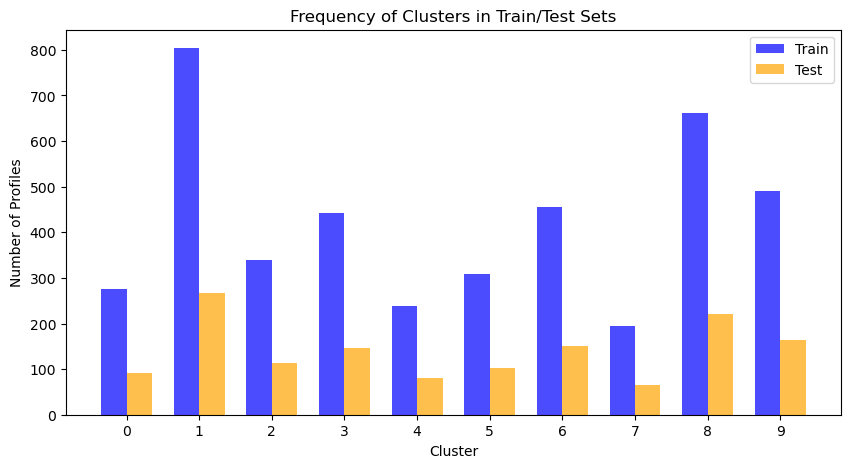

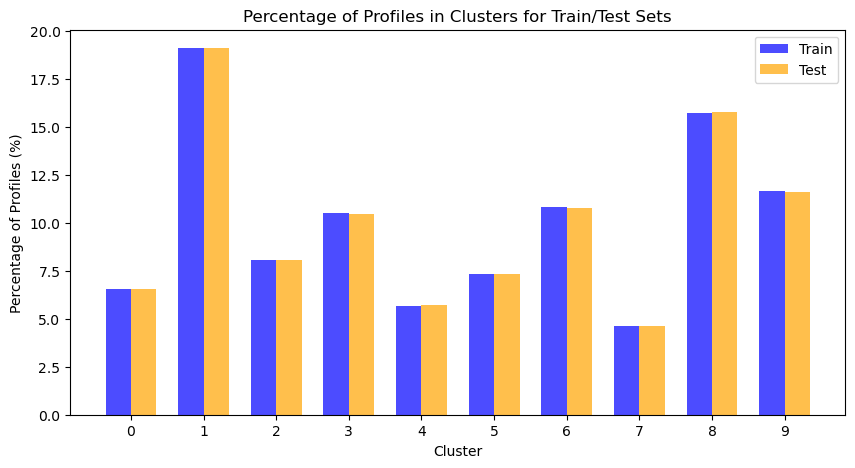

In [14]:
merged_clusters = merged.copy()

# plot frequency of clusters in train/test
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
train_clusters = merged_clusters[merged_clusters['data_type'] != 'test']['cluster'].value_counts().sort_index()
test_clusters = merged_clusters[merged_clusters['data_type'] == 'test']['cluster'].value_counts().sort_index()
width = 0.35
plt.bar(train_clusters.index - width/2, train_clusters.values, width=width, label='Train', color='blue', alpha=0.7)
plt.bar(test_clusters.index + width/2, test_clusters.values, width=width, label='Test', color='orange', alpha=0.7)
plt.xlabel('Cluster')
plt.ylabel('Number of Profiles')
plt.title('Frequency of Clusters in Train/Test Sets')
plt.xticks(train_clusters.index)
plt.legend()
plt.show()

# plot the percent of profiles in train and test set that are in each cluster
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
total_profiles_train = len(merged_clusters[merged_clusters['data_type'] != 'test'])
total_profiles_test = len(merged_clusters[merged_clusters['data_type'] == 'test'])

train_percent = merged_clusters[merged_clusters['data_type'] != 'test']['cluster'].value_counts().sort_index() / total_profiles_train * 100
test_percent = merged_clusters[merged_clusters['data_type'] == 'test']['cluster'].value_counts().sort_index() / total_profiles_test * 100
width = 0.35
plt.bar(train_percent.index - width/2, train_percent.values, width=width, label='Train', color='blue', alpha=0.7)
plt.bar(test_percent.index + width/2, test_percent.values, width=width, label='Test', color='orange', alpha=0.7)
plt.xlabel('Cluster')
plt.ylabel('Percentage of Profiles (%)')
plt.title('Percentage of Profiles in Clusters for Train/Test Sets')
plt.xticks(train_percent.index)
plt.legend()
plt.show()


## Validation folds

Input data:  5613 total profiles
Data types: {'train': 4210, 'test': 1403}
Training profiles: 4210, requested folds: 4
Assigning 4210 training profiles to 4 CV folds...
Progress: 25% (1052/4210 profiles assigned)
Current fold sizes: [1052, 0, 0, 0]
Progress: 50% (2105/4210 profiles assigned)
Current fold sizes: [1062, 1043, 0, 0]
Progress: 75% (3157/4210 profiles assigned)
Current fold sizes: [1062, 1062, 1033, 0]
Progress: 100% (4210/4210 profiles assigned)
Current fold sizes: [1062, 1062, 1062, 1024]
Final fold sizes: [1062, 1062, 1062, 1024]
Assignment complete:  4210 profiles assigned
Fold 1: 1062 profiles, clusters: {0: 68, 1: 203, 2: 84, 3: 116, 4: 59, 5: 77, 6: 117, 7: 48, 8: 165, 9: 125}
Fold 2: 1062 profiles, clusters: {0: 69, 1: 203, 2: 84, 3: 113, 4: 60, 5: 78, 6: 115, 7: 48, 8: 168, 9: 124}
Fold 3: 1062 profiles, clusters: {0: 69, 1: 201, 2: 85, 3: 110, 4: 61, 5: 79, 6: 113, 7: 49, 8: 169, 9: 126}
Fold 4: 1024 profiles, clusters: {0: 69, 1: 197, 2: 86, 3: 104, 4: 59, 5: 74,

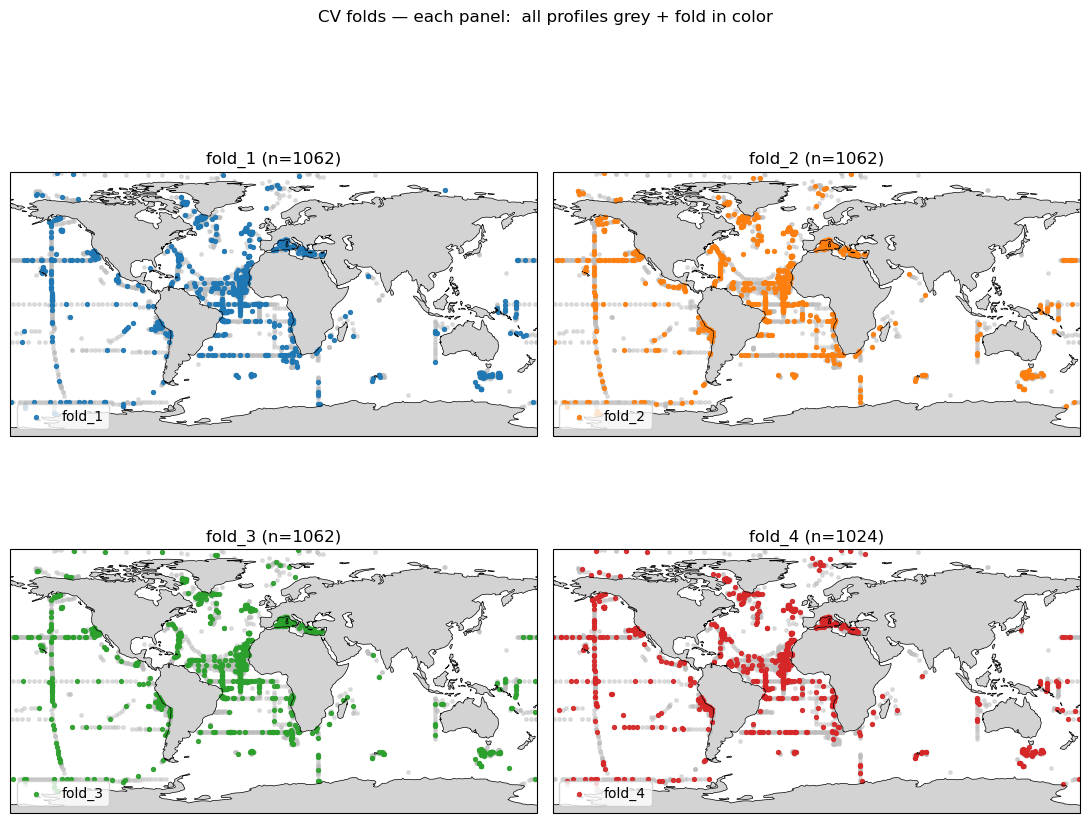


Final CV fold distribution:
fold_1: 1062 profiles
fold_2: 1062 profiles
fold_3: 1062 profiles
fold_4: 1024 profiles

Done — merged['CV_fold'] updated. Mapping saved to: ../Data\Profile_id_to_train_test_cross_val.pkl


In [19]:
"""
Notebook-friendly:  split training profiles into CV folds using balanced selection,
ensuring roughly equal profile counts and geographic distribution across folds.  

Inputs:
- `merged` DataFrame already loaded in the notebook.  Must contain columns:
  ['Profile_id','Latitude','Longitude','datetime','data_type', 'cluster']

Outputs:
- Adds/overwrites merged['CV_fold'] with 'fold_1'. .'fold_K' for training rows and '' for test rows.  
- Saves mapping pickle to ../Data/Profile_id_to_train_test_cross_val. pkl with columns [Profile_id, data_type, CV_fold]. 
- Displays multi-panel map:  one panel per fold (all points grey, fold in color).

Adjust parameters in the CONFIG block below.  
"""
import os
import random
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional cartopy for nicer maps
HAS_CARTOPY = False
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False

# ============== CONFIG ==============
RANDOM_SEED = 2025
N_CV_FOLDS = 4
CLUSTER_WEIGHT = 2.0                # weight for cluster balance across folds
GEO_WEIGHT = 1.0                    # weight for geographic balance across folds
SAMPLE_SIZE = 1000                  # sample size when many profiles remain

LAT_BIN_EDGES = [10, 30, 50, 70, 90]  # absolute-latitude edges for geographic binning
LON_BIN_WIDTH = 20.0                   # longitude bin width

OUT_DIR = "../Data"
OUT_PKL = os.path.join(OUT_DIR, "Profile_id_to_train_test_cross_val.pkl")
SAVE_MAPPING = True
# ====================================

def set_seed(s):
    random.seed(s)
    np.random.seed(s)

def require_merged():
    if 'merged' not in globals() or not isinstance(globals()['merged'], pd.DataFrame):
        raise RuntimeError("Please load your table into the notebook variable `merged` before running this cell.")
    return globals()['merged']

def make_abs_lat_bins(df, edges):
    lat_abs = df['Latitude'].abs().astype(float)
    edges_sorted = sorted(edges)
    if edges_sorted[0] != 0.0:
        edges_sorted = [0.0] + edges_sorted
    if edges_sorted[-1] < 90.0:
        edges_sorted = edges_sorted + [90.0]
    labels = []
    for i in range(len(edges_sorted)-1):
        labels.append(f"{int(edges_sorted[i])}-{int(edges_sorted[i+1])}")
    bins = pd.cut(lat_abs, bins=edges_sorted, labels=labels, include_lowest=True, right=False)
    return bins.astype(str)

def make_lon_bins(df, width_deg):
    lon = (pd.to_numeric(df['Longitude'], errors='coerce') + 180.0) % 360.0 - 180.0
    edges = np.arange(-180.0, 180.0 + 1e-6, width_deg)
    bins = pd.cut(lon, bins=edges, include_lowest=True, right=False)
    return bins.astype(str)

def summarize_geo(rows):
    return {
        'lat': rows['lat_abs_bin'].value_counts().to_dict(),
        'lon': rows['lon_bin'].value_counts().to_dict(),
        'spatial': rows['spatial_bin'].value_counts().to_dict()
    }

def summarize_cluster(rows):
    return rows['cluster'].value_counts().to_dict()

def l1dist(a, b):
    keys = set(a.keys()) | set(b.keys())
    return sum(abs(a.get(k, 0) - b.get(k, 0)) for k in keys)

def score_fold_balance(fold_counts, target_counts):
    """Score how well current fold distribution matches target"""
    geo_score = 0
    cluster_score = 0
    
    for fold_geo, fold_cluster in fold_counts:  
        geo_score += l1dist(fold_geo['lat'], target_counts['geo']['lat'])
        geo_score += l1dist(fold_geo['lon'], target_counts['geo']['lon']) 
        geo_score += l1dist(fold_geo['spatial'], target_counts['geo']['spatial'])
        cluster_score += l1dist(fold_cluster, target_counts['cluster'])
    
    return CLUSTER_WEIGHT * cluster_score + GEO_WEIGHT * geo_score

def assign_folds_balanced_greedy(df_train, n_folds):
    """
    Assign training profiles to CV folds using greedy balanced selection
    """
    print(f"Assigning {len(df_train)} training profiles to {n_folds} CV folds...")
    
    # Calculate target distributions per fold
    total_profiles = len(df_train)
    profiles_per_fold = total_profiles // n_folds
    
    target_geo = summarize_geo(df_train)
    target_cluster = summarize_cluster(df_train)
    
    # Scale targets down to per-fold level
    target_per_fold = {
        'geo': {
            'lat': {k: v // n_folds for k, v in target_geo['lat'].items()},
            'lon': {k: v // n_folds for k, v in target_geo['lon'].items()},
            'spatial': {k: v // n_folds for k, v in target_geo['spatial'].items()}
        },
        'cluster': {k: v // n_folds for k, v in target_cluster.items()}
    }
    
    # Initialize fold assignments
    fold_assignments = [[] for _ in range(n_folds)]
    fold_geo_counts = [{'lat': defaultdict(int), 'lon': defaultdict(int), 'spatial': defaultdict(int)} for _ in range(n_folds)]
    fold_cluster_counts = [defaultdict(int) for _ in range(n_folds)]
    fold_sizes = [0] * n_folds
    
    # Get all training profile IDs
    all_train_profiles = df_train['Profile_id'].tolist()
    remaining_profiles = set(all_train_profiles)
    
    # Progress tracking
    total_to_assign = len(remaining_profiles)
    assigned = 0
    progress_intervals = [int(total_to_assign * p) for p in [0.25, 0.5, 0.75, 1.0]]
    
    # Greedy assignment
    while remaining_profiles: 
        # For speed, sample if too many remaining
        if len(remaining_profiles) > SAMPLE_SIZE:
            sample_profiles = random.sample(list(remaining_profiles), SAMPLE_SIZE)
        else:
            sample_profiles = list(remaining_profiles)
        
        best_profile = None
        best_fold = None
        best_score_improvement = float('-inf')
        
        for profile_id in sample_profiles:  
            profile_row = df_train[df_train['Profile_id'] == profile_id].iloc[0]
            
            # Try assigning this profile to each fold
            for fold_idx in range(n_folds):
                # Skip if this fold is already much larger than target
                if fold_sizes[fold_idx] >= profiles_per_fold + 10:
                    continue
                
                # Calculate score improvement if we add this profile to this fold
                trial_geo = {
                    'lat': dict(fold_geo_counts[fold_idx]['lat']),
                    'lon': dict(fold_geo_counts[fold_idx]['lon']),
                    'spatial': dict(fold_geo_counts[fold_idx]['spatial'])
                }
                trial_geo['lat'][profile_row['lat_abs_bin']] = trial_geo['lat'].get(profile_row['lat_abs_bin'], 0) + 1
                trial_geo['lon'][profile_row['lon_bin']] = trial_geo['lon'].get(profile_row['lon_bin'], 0) + 1
                trial_geo['spatial'][profile_row['spatial_bin']] = trial_geo['spatial'].get(profile_row['spatial_bin'], 0) + 1
                
                trial_cluster = dict(fold_cluster_counts[fold_idx])
                cluster_key = int(profile_row['cluster'])  # Convert to regular Python int
                trial_cluster[cluster_key] = trial_cluster.get(cluster_key, 0) + 1
                
                # Score how close this fold would be to target
                geo_score = (l1dist(trial_geo['lat'], target_per_fold['geo']['lat']) +
                           l1dist(trial_geo['lon'], target_per_fold['geo']['lon']) +
                           l1dist(trial_geo['spatial'], target_per_fold['geo']['spatial']))
                
                cluster_score = l1dist(trial_cluster, target_per_fold['cluster'])
                
                combined_score = CLUSTER_WEIGHT * cluster_score + GEO_WEIGHT * geo_score
                
                # Also penalize size imbalance
                size_penalty = abs(fold_sizes[fold_idx] + 1 - profiles_per_fold)
                
                total_score = combined_score + 0.1 * size_penalty
                
                # We want to minimize the score (lower is better)
                score_improvement = -total_score
                
                if score_improvement > best_score_improvement:
                    best_score_improvement = score_improvement
                    best_profile = profile_id
                    best_fold = fold_idx
        
        # Assign best profile to best fold
        if best_profile is not None:  
            profile_row = df_train[df_train['Profile_id'] == best_profile].iloc[0]
            
            fold_assignments[best_fold].append(best_profile)
            fold_geo_counts[best_fold]['lat'][profile_row['lat_abs_bin']] += 1
            fold_geo_counts[best_fold]['lon'][profile_row['lon_bin']] += 1
            fold_geo_counts[best_fold]['spatial'][profile_row['spatial_bin']] += 1
            
            cluster_key = int(profile_row['cluster'])  # Convert to regular Python int
            fold_cluster_counts[best_fold][cluster_key] += 1
            fold_sizes[best_fold] += 1
            
            remaining_profiles.remove(best_profile)
            assigned += 1
            
            # Progress reporting
            if assigned in progress_intervals:
                progress = assigned / total_to_assign * 100
                print(f"Progress: {progress:.0f}% ({assigned}/{total_to_assign} profiles assigned)")
                print(f"Current fold sizes: {fold_sizes}")
        else:
            # Fallback: assign remaining profiles round-robin
            print("Greedy selection complete, assigning remaining profiles round-robin...")
            remaining_list = list(remaining_profiles)
            for i, profile_id in enumerate(remaining_list):
                fold_idx = i % n_folds
                fold_assignments[fold_idx].append(profile_id)
                fold_sizes[fold_idx] += 1
            break
    
    # Create profile_id -> fold mapping
    profile_to_fold = {}
    for fold_idx, profile_list in enumerate(fold_assignments):
        for profile_id in profile_list:
            profile_to_fold[profile_id] = fold_idx
    
    print(f"Final fold sizes: {fold_sizes}")
    print(f"Assignment complete:  {len(profile_to_fold)} profiles assigned")
    
    # Print fold statistics
    for fold_idx in range(n_folds):
        fold_profiles = df_train[df_train['Profile_id'].isin(fold_assignments[fold_idx])]
        fold_cluster_dist = fold_profiles['cluster'].value_counts().to_dict()
        print(f"Fold {fold_idx + 1}: {len(fold_profiles)} profiles, clusters: {dict(sorted(fold_cluster_dist.items()))}")
    
    return profile_to_fold

def map_and_save(merged_df, profile_to_fold, n_folds, out_pkl=OUT_PKL, save_mapping=SAVE_MAPPING):
    """Map profile assignments back to dataframe and save"""
    df = merged_df.copy()
    
    # Initialize CV_fold
    df['CV_fold'] = ''
    
    # Assign for train rows
    train_mask = df['data_type'] == 'train'
    for profile_id, fold_idx in profile_to_fold.items():
        mask = (df['Profile_id'] == profile_id) & train_mask
        df.loc[mask, 'CV_fold'] = f"fold_{fold_idx + 1}"
    
    # Check for unassigned training profiles
    unassigned = df[train_mask & (df['CV_fold'] == '')].shape[0]
    if unassigned > 0:
        print(f"Warning: {unassigned} training profiles were not assigned to folds")
    
    # Test rows keep CV_fold empty
    df.loc[df['data_type'] != 'train', 'CV_fold'] = ''
    
    # Save mapping
    mapping = df[['Profile_id', 'data_type', 'CV_fold']].copy()
    if save_mapping:
        os.makedirs(os.path.dirname(out_pkl), exist_ok=True)
        mapping.to_pickle(out_pkl)
        print(f"Saved mapping to: {out_pkl}")
    
    return df, mapping

def plot_fold_panels(df_with_folds, n_folds):
    """Plot multi-panel map showing each fold"""
    palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    folds = [f"fold_{i+1}" for i in range(n_folds)]
    
    ncols = min(2, n_folds)
    nrows = int(np.ceil(n_folds / ncols))
    figsize = (5.5 * ncols, 4.5 * nrows)
    
    if HAS_CARTOPY:
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
    else:
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    
    if nrows == 1 and ncols == 1:
        axes = [axes]
    elif nrows == 1 or ncols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()

    lon_all = df_with_folds['Longitude'].to_numpy()
    lat_all = df_with_folds['Latitude'].to_numpy()

    for i, fold in enumerate(folds):
        ax = axes[i]
        if HAS_CARTOPY:  
            ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
            ax.add_feature(cfeature.LAND, facecolor='lightgray')
            ax.set_global()
            ax.scatter(lon_all, lat_all, s=6, c='#bdbdbd', alpha=0.45, transform=ccrs.PlateCarree())
            sub = df_with_folds[df_with_folds['CV_fold'] == fold]
            if len(sub) > 0:
                ax.scatter(sub['Longitude'], sub['Latitude'], s=8, c=palette[i % len(palette)], 
                         alpha=0.9, transform=ccrs.PlateCarree(), label=fold)
        else:
            ax.set_facecolor('lightgray')
            ax.scatter(lon_all, lat_all, s=6, c='#bdbdbd', alpha=0.45)
            sub = df_with_folds[df_with_folds['CV_fold'] == fold]
            if len(sub) > 0:
                ax.scatter(sub['Longitude'], sub['Latitude'], s=8, c=palette[i % len(palette)], 
                         alpha=0.9, label=fold)
            ax.set_xlim(-180, 180)
            ax.set_ylim(-90, 90)
            ax.set_xlabel('Longitude')
            ax.set_ylabel('Latitude')
        
        ax.set_title(f"{fold} (n={len(sub)})")
        if len(sub) > 0:
            ax.legend(loc='lower left', frameon=True)

    # Hide extra axes if any
    for j in range(n_folds, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle("CV folds — each panel:  all profiles grey + fold in color", y=1.02)
    plt.tight_layout()
    plt.show()

# ----------------- Main execution -----------------
def main():
    set_seed(RANDOM_SEED)
    merged_df = require_merged()
    
    print(f"Input data:  {len(merged_df)} total profiles")
    print(f"Data types: {merged_df['data_type'].value_counts().to_dict()}")
    
    # Create geographic and cluster bins for balancing
    merged_df['lat_abs_bin'] = make_abs_lat_bins(merged_df, LAT_BIN_EDGES)
    merged_df['lon_bin'] = make_lon_bins(merged_df, LON_BIN_WIDTH)
    merged_df['spatial_bin'] = merged_df['lat_abs_bin'].astype(str) + " | " + merged_df['lon_bin'].astype(str)
    
    # Get training data only
    df_train = merged_df[merged_df['data_type'] == 'train'].copy()
    n_train_profiles = len(df_train)
    
    print(f"Training profiles: {n_train_profiles}, requested folds: {N_CV_FOLDS}")
    
    if n_train_profiles < N_CV_FOLDS * 10:
        print(f"Warning: Few training profiles ({n_train_profiles}) for {N_CV_FOLDS} folds")
    
    # Assign folds using balanced greedy selection
    profile_to_fold_map = assign_folds_balanced_greedy(df_train, N_CV_FOLDS)
    
    # Map back to full dataframe and save
    merged_with_folds, mapping = map_and_save(merged_df, profile_to_fold_map, N_CV_FOLDS, 
                                            out_pkl=OUT_PKL, save_mapping=SAVE_MAPPING)
    
    # Plot multi-panel map
    plot_fold_panels(merged_with_folds, N_CV_FOLDS)
    
    # Final diagnostics
    print("\nFinal CV fold distribution:")
    fold_counts = merged_with_folds[merged_with_folds['data_type'] == 'train']['CV_fold'].value_counts()
    for fold in [f"fold_{i+1}" for i in range(N_CV_FOLDS)]:
        count = fold_counts.get(fold, 0)
        print(f"{fold}: {count} profiles")
    
    # Update global variable
    globals()['merged'] = merged_with_folds
    print(f"\nDone — merged['CV_fold'] updated. Mapping saved to: {OUT_PKL if SAVE_MAPPING else 'not saved'}")
    
    return merged_with_folds, mapping

if __name__ == "__main__": 
    merged_with_folds, mapping = main()

In [20]:
df = pd.read_pickle('../Data/Profile_id_to_train_test_cross_val.pkl')
df.head(40)

,Profile_id,data_type,CV_fold
0,s033,train,fold_3
1,s035,train,fold_2
2,s034,test,
3,s036,train,fold_3
4,s037,train,fold_1
5,s038,train,fold_2
6,s039,test,
7,s040,train,fold_1
8,s041,test,
9,s042,train,fold_2


In [21]:
# percent of profiles in each fold and data_type
total_profiles = len(df)
fold_counts = df[df['data_type']=='train']['CV_fold'].value_counts().sort_index()
test_count = len(df[df['data_type']=='test'])
print(f"Total profiles: {total_profiles}")
print(f"Training profiles: {total_profiles - test_count}")
print("Training fold counts and percentages:")
for fold, count in fold_counts.items():
    percent = (count / total_profiles) * 100
    print(f"{fold}: {count} profiles ({percent:.2f}%)")
print(f"\nTest set: {test_count} profiles ({(test_count / total_profiles) * 100:.2f}%)")

Total profiles: 5613
Training profiles: 4210
Training fold counts and percentages:
fold_1: 1062 profiles (18.92%)
fold_2: 1062 profiles (18.92%)
fold_3: 1062 profiles (18.92%)
fold_4: 1024 profiles (18.24%)

Test set: 1403 profiles (25.00%)


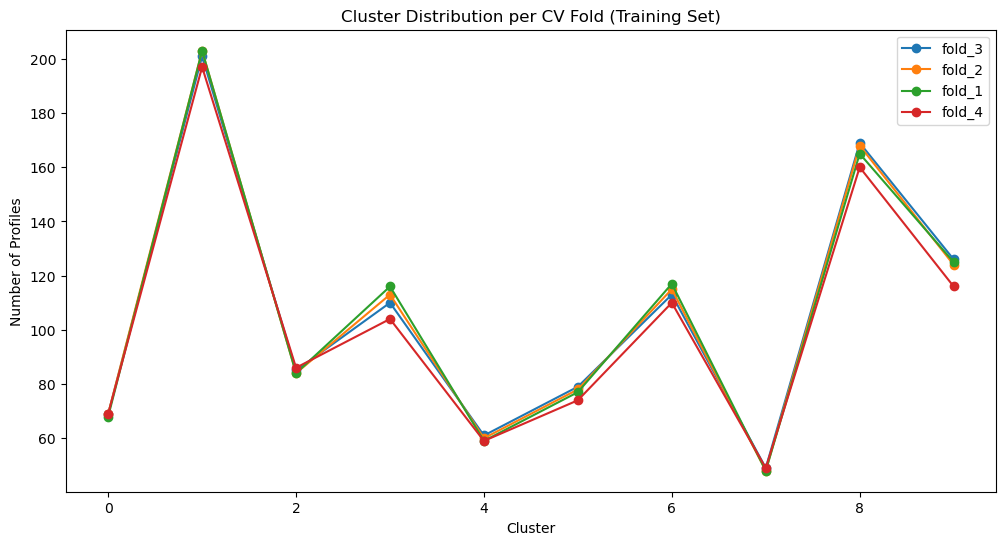

In [22]:
# merge df with data to get cluster info
merged_clusters = df.merge(data[['Profile_id','cluster']], on='Profile_id', how='left')

# how is the distribution of profiles across clusters per fold (train only), bar plot
import matplotlib.pyplot as plt
train_df = merged_clusters[merged_clusters['data_type']=='train']
folds = train_df['CV_fold'].unique().tolist()
plt.figure(figsize=(12,6))
for fold in folds:
    sub = train_df[train_df['CV_fold']==fold]
    cluster_counts = sub['cluster'].value_counts().sort_index()
    plt.plot(cluster_counts.index, cluster_counts.values, marker='o', label=fold)
plt.xlabel('Cluster')
plt.ylabel('Number of Profiles')
plt.title('Cluster Distribution per CV Fold (Training Set)')
plt.legend()
plt.show()